
<div style="text-align: center; background-color: lightblue; padding: 15px;">
    <p style="text-align: center;">بسم الله، والحمد لله، والصلاة والسلام على رسول الله وعلى آله وصحبه</p>
</div>

# I- NECESSARY TOOLS

In [1]:
from me_r_sy.ingestion.grib import get_grib , get_var
from me_r_sy.visualization.plots import plot_it , plot_wind
from me_r_sy.analysis.statistics import get_stat , ref_avg 
import geopandas as gpd
import numpy as np
import yaml
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import calendar
import argparse

In [20]:
# read the config file
config_file = "/home/muhammed/METEO-REPORTING-SYSTEM/ME_R_SY/config/config_feb.yml"
with open(config_file , "r") as f :
    config = yaml.safe_load(f)

In [21]:
cmap_dict = {
    "2t" : "RdYlBu_r" , 
    "tp"  : "GnBu" , 
    "msl" : "viridis" , 
    "w"   : "YlOrRd"
}


cmap_dict_anom = {
    "2t" : "bwr" , 
    "tp"  : "PuOr" , 
    "msl" : "BrBG" , 
    "w"   : "RdGy"
}

In [22]:
year       = config["date"]["year"]
month      = config["date"]["month"]
input_dir  = config["data"]["input"] 
ref_dir    = f"{input_dir}/reference_1991_2020.grib"
output_dir = config["data"]["output"] 
shp_path   = config["data"]["shapefile"]
year       = config["date"]["year"]
month      = config["date"]["month"]

# II- READ DATA

In [23]:
# read the shapefile
grib_path = f"{input_dir}/input_{year}_{month:02d}.grib"
ref_path  = f"{input_dir}/reference_1991_2020.grib"
shp = gpd.read_file(shp_path)
ds        = get_grib(grib_path)
ds_ref    = get_grib(ref_path)
ref_mean  = list(map(ref_avg , ds_ref))
month_range = calendar.monthrange(year , month)[1]
# get vars
t   = get_var(ds , "t2m")
u   = get_var(ds , "u10")
v   = get_var(ds , "v10")
w   = np.sqrt(u**2 + v**2) 
tp  = get_var(ds , "tp")
w.attrs["GRIB_shortName"] = "w"
w.attrs["long_name"] = "wind speed"
p   = get_var(ds , "msl") 

# # get monthly vars
# u_m  = u.resample(time = "ME").mean().squeeze()
t_m  = get_stat(t , np.mean , "ME") 
u_m  = get_stat(u , np.mean , "ME") 
v_m  = get_stat(v , np.mean , "ME") 
w_m  = get_stat(w , np.mean , "ME")
p_m  = get_stat(p , np.mean , "ME") 
tp_m = tp.sum(dim = 'step').sum(dim = "time")
# tp_m = tp[:,-1,:,:].sum(dim = "time")
# read the reference period variables

t_ref   = get_var(ref_mean , "t2m").sel(month = month)
u_ref   = get_var(ref_mean , "u10").sel(month = month)
v_ref   = get_var(ref_mean , "v10").sel(month = month)
w_ref   = np.sqrt(u_ref**2 + v_ref**2)
w_ref.attrs["GRIB_shortName"] = "w"
w_ref.attrs["long_name"] = "wind speed"
tp_ref  = get_var(ref_mean , "tp").sel(month = month)*month_range
p_ref   = get_var(ref_mean , "msl").sel(month = month)

# calculate the anomaly

t_anom  = t_m  - t_ref 
p_anom  = p_m  - p_ref
tp_anom = tp_m - tp_ref 
u_anom  = u_m  - u_ref
v_anom  = v_m  - v_ref 
w_anom  = w_m  - w_ref

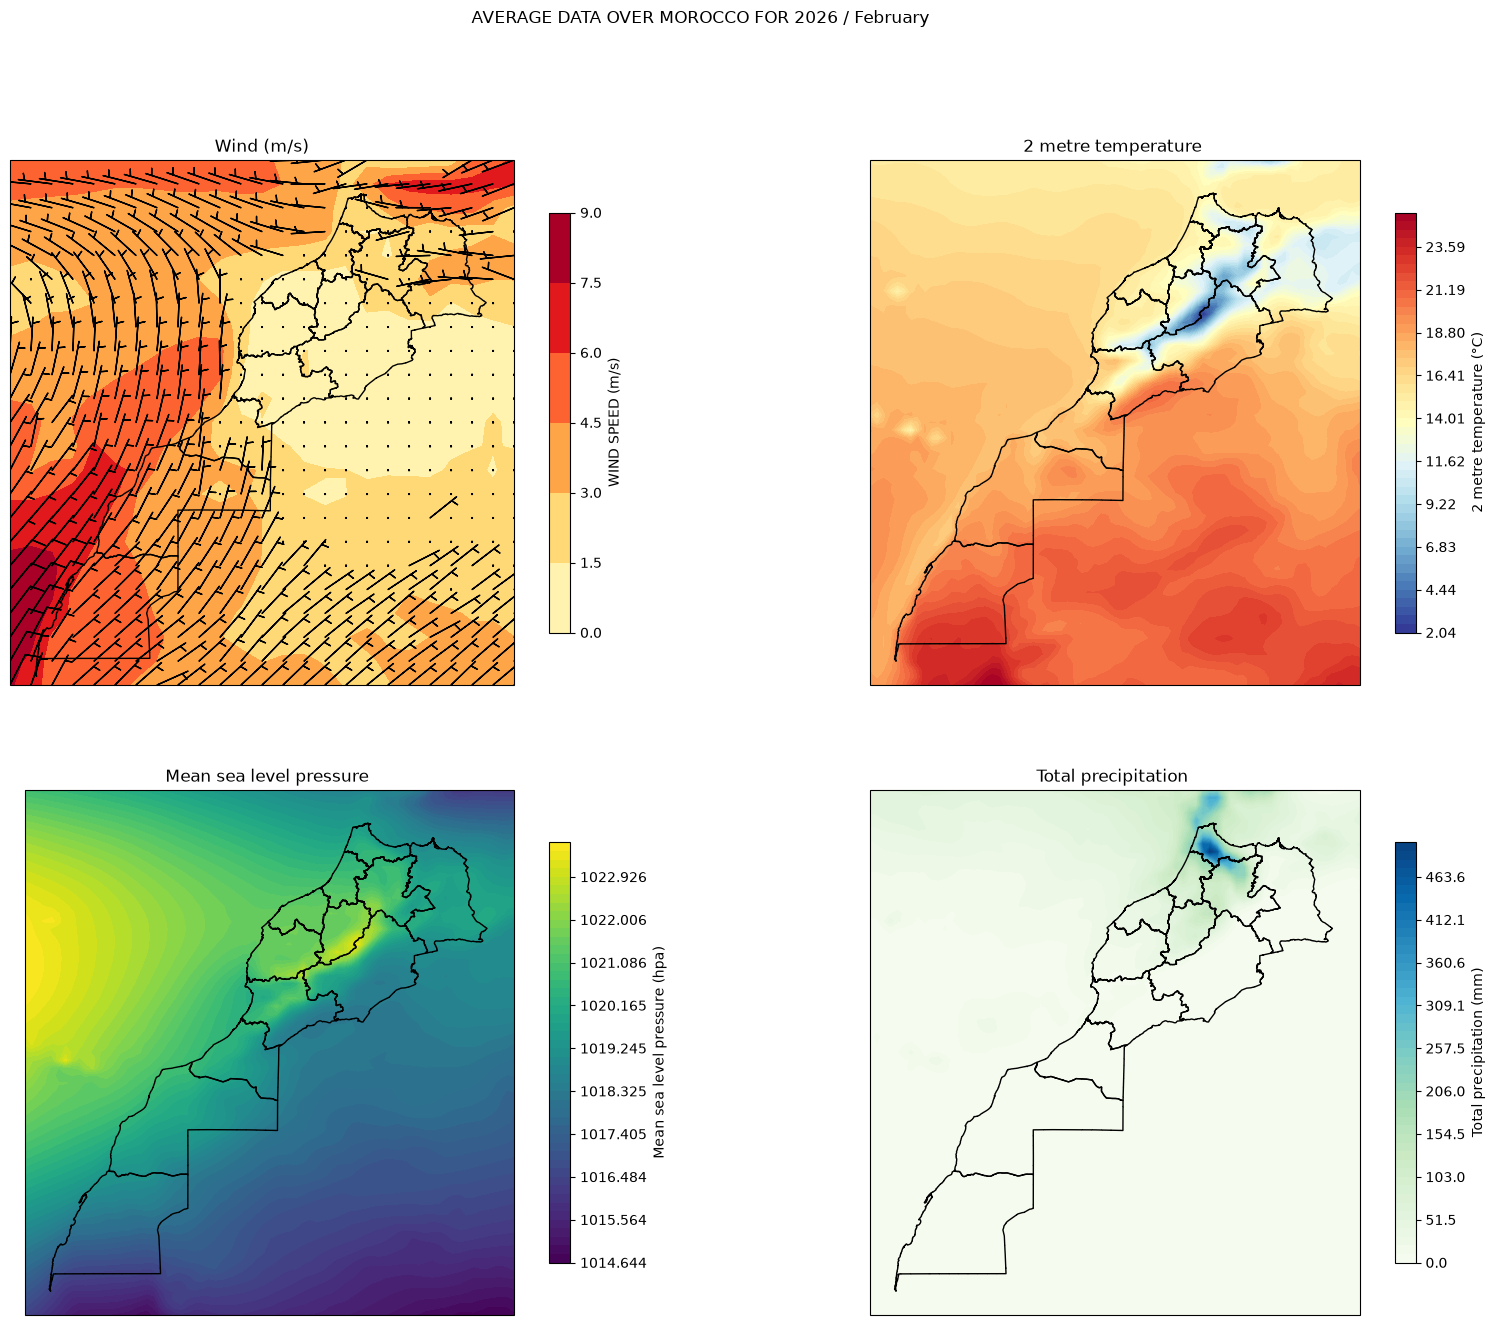

In [24]:
fig , ax = plt.subplots(figsize = (20,15) , ncols = 2 , nrows = 2 , subplot_kw = {"projection" : ccrs.PlateCarree()})
ax = ax.flatten()
plot_wind(fig , ax[0] , u_m , v_m  , shp , year , month)
for i , var in enumerate([t_m , p_m , tp_m]) : 
    plot_it(fig , ax[i+1] , var , shp , year , month , cmap_dict ) 
    plt.savefig(f"{output_dir}/plots.png")


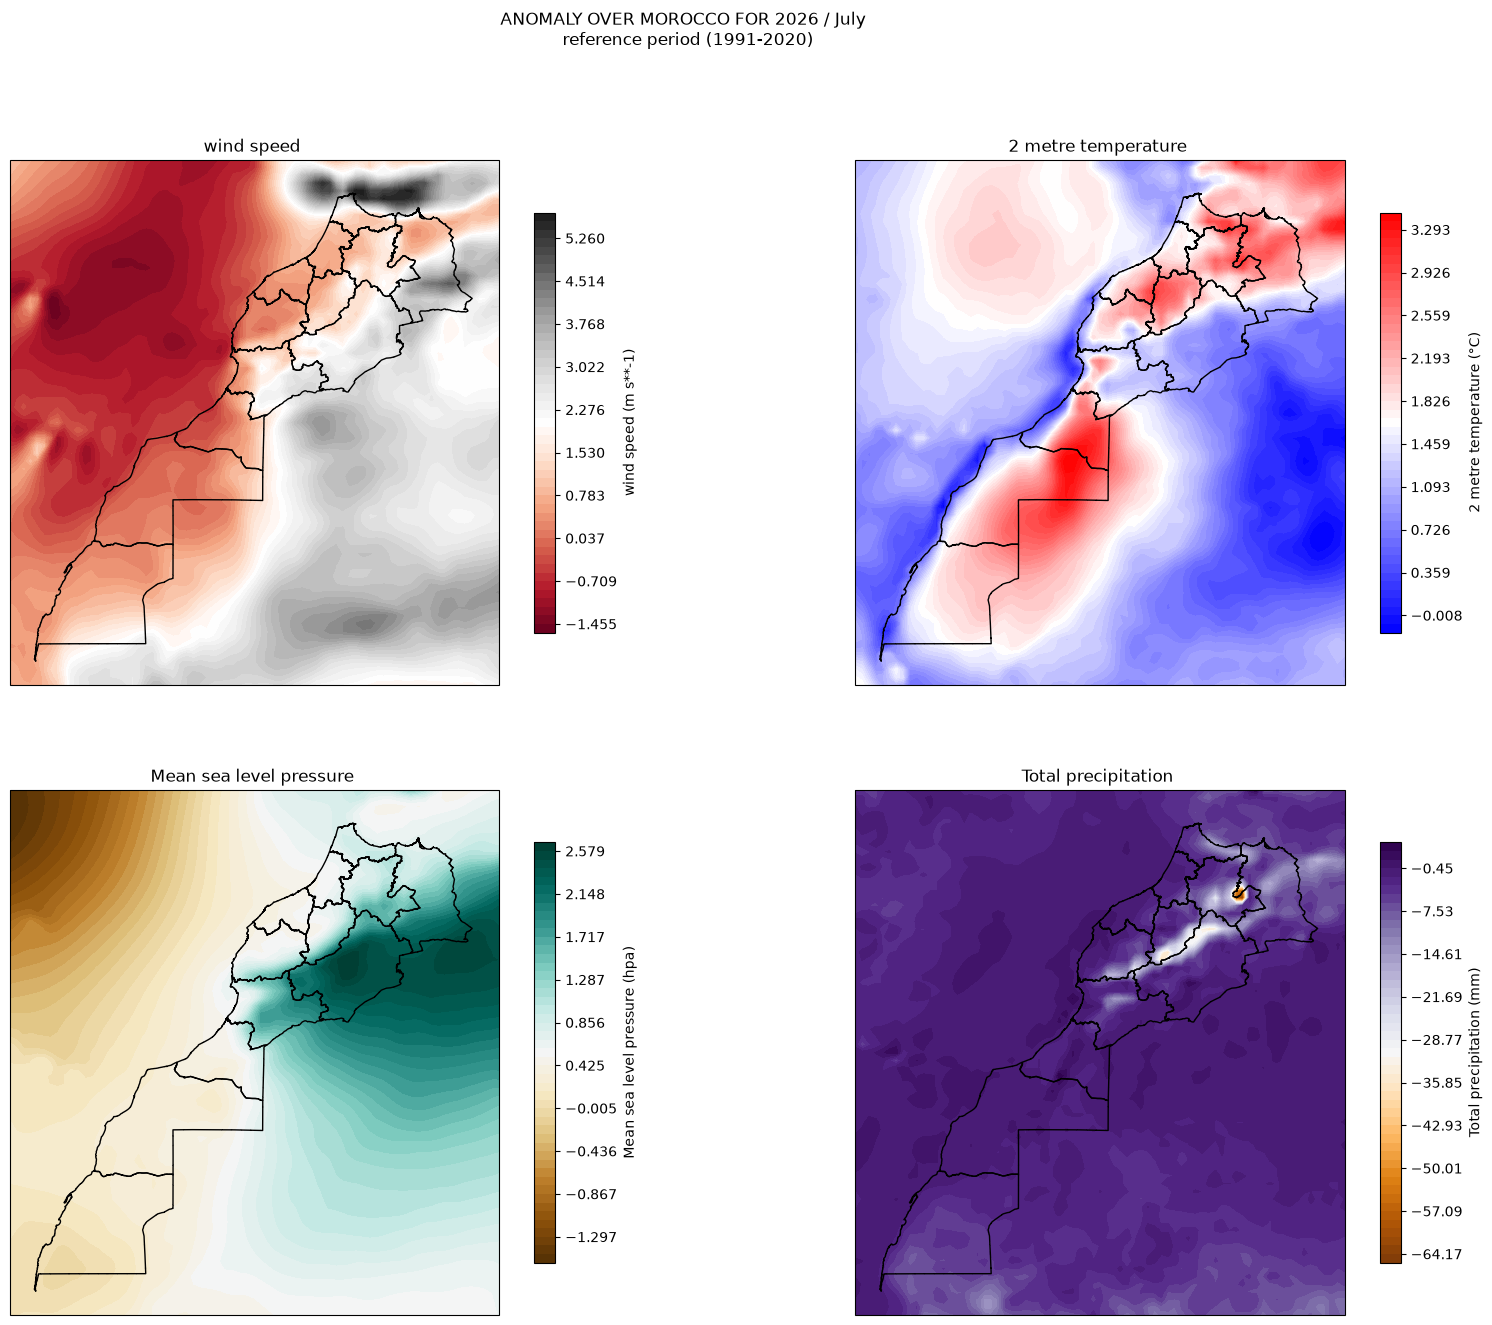

In [126]:
fig , ax = plt.subplots(figsize = (20,15) , ncols = 2 , nrows = 2 , subplot_kw = {"projection" : ccrs.PlateCarree()})
ax = ax.flatten()
for i , var in enumerate([w_anom , t_anom , p_anom , tp_anom]) : 
    plot_it(fig , ax[i] , var , shp , year , month , cmap_dict_anom) 
    plt.suptitle(f"ANOMALY OVER MOROCCO FOR {year} / {calendar.month_name[month]} \n reference period (1991-2020)")
    plt.savefig(f"{output_dir}/anom.png")
